# 04 - REINFORCE robot debugging lab

Continue [notebook 03](03_coordinated_baseline.ipynb). Debug the learning code, train the robot,
and compare recorded behavior. [Issue #33](https://github.com/haidmoham/spider/issues/33).

Deliberately flawed learning draft. No robot training ran during preparation.

## Setup

Use the **C-1N pairing** kernel. Run setup and the carried code once.

In [1]:
from pathlib import Path
import sys

REPO_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
                 if (p / "spider" / "learning.py").is_file())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import mujoco
import numpy as np
import pandas as pd
from spider.learning import LearningSimulation, record_policy, plot_recordings
from spider.simulation import neutral_targets

sim = LearningSimulation()
actuator_names = [sim.model.actuator(i).name for i in range(sim.model.nu)]
print("Physics timestep (s):", sim.model.opt.timestep)
display(pd.DataFrame({
    "index": range(sim.model.nu), "actuator": actuator_names,
    "neutral_rad": neutral_targets(),
    "target_min_rad": sim.model.actuator_ctrlrange[:, 0],
    "target_max_rad": sim.model.actuator_ctrlrange[:, 1],
}))

Physics timestep (s): 0.002


,index,actuator,neutral_rad,target_min_rad,target_max_rad
0,0,front_left_coxa_motor,0.0,-0.8,0.8
1,1,front_left_hip_motor,-0.2,-0.8,0.8
2,2,front_left_knee_motor,1.1,-1.4,1.4
3,3,front_right_coxa_motor,0.0,-0.8,0.8
4,4,front_right_hip_motor,-0.2,-0.8,0.8
5,5,front_right_knee_motor,1.1,-1.4,1.4
6,6,middle_left_coxa_motor,0.0,-0.8,0.8
7,7,middle_left_hip_motor,-0.2,-0.8,0.8
8,8,middle_left_knee_motor,1.1,-1.4,1.4
9,9,middle_right_coxa_motor,0.0,-0.8,0.8


### Reference code from notebook 03

Geometry helpers, fixed shuffle, and feedback policy. No rollout runs in these cells.
Source: notebook 03 at `e6ba912`; original results remain there.

In [2]:
# Next: which joint moves each foot forward/backward near the neutral pose?
# Runs geometry diagnostics only: no time stepping, viewer, training, or gait search.
# During stance, the floor supports the body against gravity. A backward push
# on the floor can produce a forward reaction on the body. First check the geometry.  
from spider.simulation import FOOT_NAMES

probe_sim = LearningSimulation()  # Separate scratch state; preserves the policy runs.
PROBE_DELTA_RAD = 0.01
PROBE_JOINTS = ("coxa", "hip", "knee")


def foot_at_offset(leg, joint, offset_rad):
    """Geometry helper: one joint offset from neutral -> foot XYZ in torso frame (m)."""
    probe_sim.reset()
    model, data = probe_sim.model, probe_sim.data
    joint_id = model.joint(f"{leg}_{joint}").id
    address = model.jnt_qposadr[joint_id]
    data.qpos[address] += offset_rad  # Set an angle directly; this is not an actuator command.
    mujoco.mj_forward(model, data)  # Recompute geometry without advancing time.
    torso_id = model.body("torso").id
    foot_id = model.geom(f"{leg}_foot").id
    rotation = data.xmat[torso_id].reshape(3, 3)
    return (rotation.T @ (data.geom_xpos[foot_id] - data.xpos[torso_id])).copy()


def foot_motion_per_radian(leg, joint, delta=PROBE_DELTA_RAD):
    """Return a 3-vector: local foot motion [dx/dq, dy/dq, dz/dq], in m/rad."""
    # Two-sided finite difference; retain the diagnostics when changing this probe.
    plus = foot_at_offset(leg, joint, delta)
    minus = foot_at_offset(leg, joint, -delta)
    return (plus - minus) / (2 * delta)

In [3]:
# Geometry-informed tripod gait.
# This is a hypothesis / visualization, not an earned locomotion result.

import numpy as np

LEGS = (
    "front_left",
    "front_right",
    "middle_left",
    "middle_right",
    "rear_left",
    "rear_right",
)

TRIPOD_A = {"front_left", "middle_right", "rear_left"}
TRIPOD_B = set(LEGS) - TRIPOD_A

# Small offsets. Keep this boring initially.
COXA_SWEEP_RAD = 0.04
LIFT_RAD = 0.05
GAIT_PERIOD_S = 0.8


# Learn local directions from geometry instead of guessing signs.
geometry = {}

for leg in LEGS:
    coxa_j = foot_motion_per_radian(leg, "coxa")

    hip_j = foot_motion_per_radian(leg, "hip")
    knee_j = foot_motion_per_radian(leg, "knee")

    lift_joint, lift_j = max(
        [("hip", hip_j), ("knee", knee_j)],
        key=lambda item: abs(item[1][2]),
    )

    # sign that makes the foot move backward in torso +X coordinates
    backward_sign = -np.sign(coxa_j[0])

    # sign that makes the selected joint move the foot upward (+Z)
    lift_sign = np.sign(lift_j[2])

    geometry[leg] = {
        "backward_sign": backward_sign,
        "lift_joint": lift_joint,
        "lift_sign": lift_sign,
        "dx_dq": coxa_j[0],
        "dz_dq": lift_j[2],
    }

geometry

{'front_left': {'backward_sign': np.float64(1.0),
  'lift_joint': 'hip',
  'lift_sign': np.float64(-1.0),
  'dx_dq': np.float64(-0.24872537012312346),
  'dz_dq': np.float64(-0.12003818291465296)},
 'front_right': {'backward_sign': np.float64(-1.0),
  'lift_joint': 'hip',
  'lift_sign': np.float64(-1.0),
  'dx_dq': np.float64(0.24872537012312346),
  'dz_dq': np.float64(-0.12003818291465296)},
 'middle_left': {'backward_sign': np.float64(1.0),
  'lift_joint': 'hip',
  'lift_sign': np.float64(-1.0),
  'dx_dq': np.float64(-0.4039969692622954),
  'dz_dq': np.float64(-0.12003818291465573)},
 'middle_right': {'backward_sign': np.float64(-1.0),
  'lift_joint': 'hip',
  'lift_sign': np.float64(-1.0),
  'dx_dq': np.float64(0.4039969692622954),
  'dz_dq': np.float64(-0.12003818291465573)},
 'rear_left': {'backward_sign': np.float64(1.0),
  'lift_joint': 'hip',
  'lift_sign': np.float64(-1.0),
  'dx_dq': np.float64(-0.24872537012312484),
  'dz_dq': np.float64(-0.1200381829146474)},
 'rear_right': 

In [4]:
def geometry_gait(state):
    offsets = np.zeros(18)

    phase = 2 * np.pi * state.time / GAIT_PERIOD_S

    for leg_index, leg in enumerate(LEGS):
        # Opposite phase for alternating tripods.
        leg_phase = phase if leg in TRIPOD_A else phase + np.pi

        swing = np.sin(leg_phase) > 0

        info = geometry[leg]

        coxa_index = leg_index * 3
        hip_index = coxa_index + 1
        knee_index = coxa_index + 2

        # stance: push foot backward
        # swing: bring foot forward
        direction = -1 if swing else 1

        offsets[coxa_index] = (
            direction
            * info["backward_sign"]
            * COXA_SWEEP_RAD
        )

        # Lift only during swing.
        if swing:
            lift_index = hip_index if info["lift_joint"] == "hip" else knee_index
            offsets[lift_index] = info["lift_sign"] * LIFT_RAD

    return offsets



# Basic policy over gait parameters: measured state -> sweep/lift -> 18 joint offsets.
# The fixed geometry_gait above remains the control. No training or rollout runs here.
# Period stays fixed: changing time / period on every call would jump the gait phase.
TARGET_SPEED_M_S = 0.03  # Editable first target, not a demonstrated capability.


SPEED_GAIN = 0.5  # rad / (m/s); a starting hypothesis, not a tuned gain.
SWEEP_MIN_RAD, SWEEP_MAX_RAD = 0.0, 0.08


def gait_parameter_policy(state, target_speed_m_s=TARGET_SPEED_M_S):
    measured_speed = state.torso_velocity[0]
    speed_error = target_speed_m_s - measured_speed

    raw_sweep_rad = COXA_SWEEP_RAD + SPEED_GAIN * speed_error
    sweep_rad = np.clip(raw_sweep_rad, SWEEP_MIN_RAD, SWEEP_MAX_RAD)

    return float(sweep_rad), float(LIFT_RAD)


# Existing gait plumbing, copied with explicit parameters instead of mutable globals.
def gait_from_parameters(state, sweep_rad, lift_rad):
    offsets = np.zeros(18)

    phase = 2 * np.pi * state.time / GAIT_PERIOD_S

    for leg_index, leg in enumerate(LEGS):
        # Opposite phase for alternating tripods.
        leg_phase = phase if leg in TRIPOD_A else phase + np.pi

        swing = np.sin(leg_phase) > 0

        info = geometry[leg]

        coxa_index = leg_index * 3
        hip_index = coxa_index + 1
        knee_index = coxa_index + 2

        # stance: push foot backward
        # swing: bring foot forward
        direction = -1 if swing else 1

        offsets[coxa_index] = (
            direction
            * info["backward_sign"]
            * sweep_rad
        )

        # Lift only during swing.
        if swing:
            lift_index = hip_index if info["lift_joint"] == "hip" else knee_index
            offsets[lift_index] = info["lift_sign"] * lift_rad

    return offsets


def basic_gait_policy(state):
    sweep_rad, lift_rad = gait_parameter_policy(state)
    return gait_from_parameters(state, sweep_rad, lift_rad)

## Train -> watch -> debug

1. Initialize a fresh run.
2. Edit the learning functions.
3. Run a training block, then evaluation/replay.
4. Inspect `last_batch`, `training_log`, `credit_log`, and `gradient_log`.

Rerun training to continue weights. Reinitialize for a fresh comparison. Save before each block.
The actor learns 18 joint offsets; the fixed shuffle is only a control. No answer key.
Collection and logging live in `lab/reinforce_inspection.py`.

In [5]:
# INITIALIZE A FRESH RUN. Rerunning resets learning; no robot rollout runs here.
import copy
from pathlib import Path
import numpy as np
import pandas as pd
import inspect
import hashlib
import json
from datetime import datetime, timezone
from importlib.metadata import version
import torch
from torch import nn
from torch.distributions import Normal
from IPython.display import display
from lab.reinforce_inspection import collect, summary, save_episode, gradient_table, plot_evaluations

SETTINGS = dict(horizon=250, physics_steps=10, bound_rad=0.05, std=0.30,
                fall_height_m=0.25, gamma=0.99, learning_rate=3e-4,
                batch_episodes=4, initialization_seed=23, train_seed=1000,
                eval_seeds=[101, 102, 103], deterministic=False)
# Draft finite-horizon task: fall/horizon ends rewards; no bootstrap.
# Start with notebook 03's 0.05 rad bound. Settings remain editable.

with torch.random.fork_rng(devices=[]):
    torch.manual_seed(SETTINGS['initialization_seed'])
    actor = nn.Sequential(nn.Linear(47, 64), nn.Tanh(), nn.Linear(64, 64),
                          nn.Tanh(), nn.Linear(64, 18))
optimizer = torch.optim.Adam(actor.parameters(), lr=SETTINGS['learning_rate'])
initial_actor = copy.deepcopy(actor)
updates = 0
training_log, credit_log, gradient_log = [], [], []
run_directory = REPO_ROOT / 'telemetry' / 'reinforce-debug' / datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S%fZ')
run_directory.mkdir(parents=True, exist_ok=False)
(run_directory / 'settings.json').write_text(json.dumps(SETTINGS, indent=2), encoding='utf-8')
torch.save({'actor': actor.state_dict(), 'optimizer': optimizer.state_dict(), 'updates': updates},
           run_directory / 'initial.pt')
receipt = dict(torch=version('torch'), mujoco=version('mujoco'),
               actor=repr(actor), helper_sha256=hashlib.sha256(
               (Path(inspect.getfile(collect))).read_bytes()).hexdigest())
(run_directory / 'environment.json').write_text(json.dumps(receipt, indent=2), encoding='utf-8')
print('Fresh run:', run_directory)
print(SETTINGS)
print('Action duration (s):', SETTINGS['physics_steps'] * sim.model.opt.timestep)

Fresh run: c:\Users\haidm\Desktop\robotics\spider\telemetry\reinforce-debug\20260915T010216441278Z
{'horizon': 250, 'physics_steps': 10, 'bound_rad': 0.05, 'std': 0.3, 'fall_height_m': 0.25, 'gamma': 0.99, 'learning_rate': 0.0003, 'batch_episodes': 4, 'initialization_seed': 23, 'train_seed': 1000, 'eval_seeds': [101, 102, 103], 'deterministic': False}
Action duration (s): 0.02


### Observation layout

47 raw values. If the size changes, update the actor and reinitialize.

| Slice | Component | Units / order |
| --- | --- | --- |
| 0:3 | Torso linear velocity | m/s, world XYZ |
| 3:6 | Torso angular velocity | rad/s, free-joint `qvel[3:6]` |
| 6:10 | Orientation | quaternion wxyz |
| 10:28 | Joint angles | rad, actuator order |
| 28:46 | Joint velocities | rad/s, actuator order |
| 46:47 | Height | m, world Z |

`episode_end` marks each episode's last row. Logs distinguish latent actions from joint commands.

In [6]:
# EDITABLE LEARNING FUNCTIONS. No training executes in this cell.
def observation_from(state):
    return torch.tensor([*state.torso_velocity, *state.torso_angular_velocity,
                         *state.torso_orientation, *state.joint_positions,
                         *state.joint_velocities, state.torso_position[2]], dtype=torch.float32)


def sample_action(network, observation, std, deterministic=False):
    distribution = Normal(network(observation), std)
    latent = distribution.mean if deterministic else distribution.sample()
    log_prob = distribution.log_prob(latent).sum()
    return latent, log_prob


def reward_terms(before, offsets_rad, after):
    return {
        'progress': float(after.torso_velocity[0]),
        'height': 0.1 * float(after.torso_position[2]),
    }


def reward_to_go(rewards, episode_end, gamma):
    returns = torch.empty_like(rewards)
    future = rewards.new_zeros(())
    for t in range(len(rewards) - 1, -1, -1):
        if episode_end[t]:
            future = rewards[t].new_zeros(())
        future = rewards[t] + gamma * future
        returns[t] = future
    return returns


def reinforce_loss(log_probs, returns):
    weights = (returns - returns.mean()) / (returns.std(unbiased=False) + 1e-8)
    return -(log_probs * weights.detach()).mean()

In [7]:
# TRAIN A BOUNDED BLOCK. Actual robot physics and optimizer steps happen here.
UPDATES_THIS_BLOCK = 20
block_directory = run_directory / f'block-{updates:05d}'
block_directory.mkdir(parents=True, exist_ok=False)
# Preserve saved notebook source plus live function source when available in IPython.
(block_directory / 'notebook.ipynb').write_bytes(
    (REPO_ROOT / 'lab/notebooks/04_mdp_contract.ipynb').read_bytes())
source_receipt = {}
for function in (observation_from, sample_action, reward_terms, reward_to_go, reinforce_loss):
    try:
        source_receipt[function.__name__] = inspect.getsource(function)
    except (OSError, TypeError):
        source_receipt[function.__name__] = 'Source unavailable; see saved notebook snapshot.'
(block_directory / 'learning-functions.json').write_text(json.dumps(source_receipt, indent=2), encoding='utf-8')
(block_directory / 'settings.json').write_text(json.dumps(SETTINGS, indent=2), encoding='utf-8')
for _ in range(UPDATES_THIS_BLOCK):
    last_batch = []
    for episode_index in range(SETTINGS['batch_episodes']):
        seed = SETTINGS['train_seed'] + updates * SETTINGS['batch_episodes'] + episode_index
        episode = collect(actor, observation_from, sample_action, reward_terms, SETTINGS,
                          seed=seed, label=f'train update {updates} episode {episode_index}', track_grad=True)
        last_batch.append(episode)
        save_episode(episode, block_directory / f'update-{updates:05d}-episode-{episode_index}')

    rows = [row for episode in last_batch for row in episode['rows']]
    rewards = torch.tensor([row['reward'] for row in rows], dtype=torch.float32)
    episode_end = torch.tensor([row['terminated'] or row['truncated'] for row in rows])
    log_probs = torch.stack([row['log_prob'] for row in rows])
    returns = reward_to_go(rewards, episode_end, SETTINGS['gamma'])
    loss = reinforce_loss(log_probs, returns)
    before_weights = copy.deepcopy(actor.state_dict())
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    gradients = gradient_table(actor).assign(update=updates)
    optimizer.step()
    weight_change = float(torch.sqrt(sum((actor.state_dict()[k] - before_weights[k]).square().sum()
                                        for k in before_weights)))
    batch_credit = pd.DataFrame(dict(
        update=updates, row=np.arange(len(rows)), episode=np.repeat(np.arange(len(last_batch)),
        [len(e['rows']) for e in last_batch]), reward=rewards.numpy(),
        episode_end=episode_end.numpy(), log_prob=log_probs.detach().numpy(),
        return_used=returns.detach().numpy()))
    credit_log.append(batch_credit)
    gradient_log.append(gradients)
    for episode in last_batch:
        training_log.append(dict(update=updates, loss=float(loss.detach()),
                                 weight_change_l2=weight_change, **summary(episode)))
    batch_credit.to_csv(block_directory / f'credit-{updates:05d}.csv', index=False)
    gradients.to_csv(block_directory / f'gradients-{updates:05d}.csv', index=False)
    print(f'update={updates} | loss={float(loss.detach()):.6g} | weight change={weight_change:.6g}')
    updates += 1
    torch.save(dict(actor=actor.state_dict(), optimizer=optimizer.state_dict(), updates=updates,
                    settings=SETTINGS), block_directory / f'checkpoint-{updates:05d}.pt')
    # Retain data for inspection without keeping consumed autograd graphs alive.
    for row in rows:
        row['log_prob'] = row['log_prob'].detach()
    del loss, log_probs, returns

pd.DataFrame(training_log).to_csv(run_directory / 'training.csv', index=False)
display(pd.DataFrame(training_log).tail(8))
display(gradient_log[-1])
display(credit_log[-1].head(12))
print('Inspect: last_batch, credit_log, gradient_log. Next: evaluate and replay.')

update=0 | loss=-0.00983416 | weight change=0.0274972
update=1 | loss=0.0606991 | weight change=0.0197436
update=2 | loss=-0.0253844 | weight change=0.0158846
update=3 | loss=-0.0349905 | weight change=0.0142074
update=4 | loss=-0.0153915 | weight change=0.0127355
update=5 | loss=0.0229728 | weight change=0.0114336
update=6 | loss=-0.0684287 | weight change=0.0111045
update=7 | loss=-0.0558795 | weight change=0.0101624
update=8 | loss=-0.113218 | weight change=0.00910196
update=9 | loss=-0.191015 | weight change=0.00825092
update=10 | loss=0.118289 | weight change=0.00813521
update=11 | loss=-0.0541111 | weight change=0.00797822
update=12 | loss=0.0222179 | weight change=0.00842889
update=13 | loss=0.144753 | weight change=0.00806038
update=14 | loss=-0.112965 | weight change=0.00804425
update=15 | loss=0.10568 | weight change=0.00777643
update=16 | loss=-0.0666559 | weight change=0.00770236
update=17 | loss=-0.0443527 | weight change=0.00773837
update=18 | loss=-0.0139156 | weight cha

,update,loss,weight_change_l2,treatment,seed,seconds,forward_m,sideways_m,minimum_height_m,total_reward,terminated,truncated,clipped_targets
72,18,-0.013916,0.008137,train update 18 episode 0,1072,5.0,-0.038297,-0.019346,0.449038,9.441131,False,True,0
73,18,-0.013916,0.008137,train update 18 episode 1,1073,5.0,0.030906,0.041365,0.448406,12.822786,False,True,0
74,18,-0.013916,0.008137,train update 18 episode 2,1074,5.0,-0.032496,0.001635,0.448901,9.671530,False,True,0
75,18,-0.013916,0.008137,train update 18 episode 3,1075,5.0,0.064520,0.064591,0.448602,14.510547,False,True,0
76,19,0.095749,0.007780,train update 19 episode 0,1076,5.0,0.050766,0.066337,0.448759,13.831546,False,True,0
77,19,0.095749,0.007780,train update 19 episode 1,1077,5.0,-0.003254,0.038956,0.449409,11.195767,False,True,0
78,19,0.095749,0.007780,train update 19 episode 2,1078,5.0,0.069390,-0.037875,0.447658,14.821088,False,True,0
79,19,0.095749,0.007780,train update 19 episode 3,1079,5.0,0.012708,0.045905,0.447226,12.013417,False,True,0


,parameter,weight_norm,grad_norm,update
0,0.weight,4.637475,0.704212,19
1,0.bias,0.711845,0.115691,19
2,2.weight,4.576616,0.867065,19
3,2.bias,0.530798,0.234248,19
4,4.weight,2.486627,0.987156,19
5,4.bias,0.356514,0.454346,19


,update,row,episode,reward,episode_end,log_prob,return_used
0,19,0,0,0.047238,False,-10.083288,5.652919
1,19,1,0,0.043403,False,-6.913671,5.662304
2,19,2,0,0.013315,False,-2.397288,5.675657
3,19,3,0,-0.014789,False,-0.735343,5.719538
4,19,4,0,0.047006,False,-2.950133,5.792249
5,19,5,0,0.103167,False,-4.929440,5.803275
6,19,6,0,0.076229,False,-5.082410,5.757685
7,19,7,0,0.204336,False,-6.130293,5.738844
8,19,8,0,0.077144,False,-1.724556,5.590412
9,19,9,0,0.071938,False,-3.568493,5.568957


Inspect: last_batch, credit_log, gradient_log. Next: evaluate and replay.


Four-pane replay opened (PID 12744): C:\Users\haidm\Desktop\robotics\spider\telemetry\reinforce-debug\20260915T010216441278Z\evaluation-00020-010251372274\views\grid-f9tc3x7y


,treatment,seed,seconds,forward_m,sideways_m,minimum_height_m,total_reward,terminated,truncated,clipped_targets
0,before stochastic seed 101,101,5.0,2.670706e-03,5.052042e-02,0.448040,11.507799,False,True,0
1,after stochastic seed 101,101,5.0,3.971743e-02,1.320912e-02,0.447924,13.349099,False,True,0
2,before stochastic seed 102,102,5.0,-1.144357e-02,1.272908e-02,0.447299,10.755969,False,True,0
3,after stochastic seed 102,102,5.0,7.872953e-04,1.548180e-03,0.449217,11.353286,False,True,0
4,before stochastic seed 103,103,5.0,2.948264e-02,-4.809390e-02,0.447859,12.776804,False,True,0
5,after stochastic seed 103,103,5.0,6.340801e-02,2.597824e-02,0.447733,14.518248,False,True,0
6,before mean,101,5.0,6.188571e-04,-1.696917e-03,0.449648,11.344728,False,True,0
7,after mean,101,5.0,7.502687e-04,-1.480910e-03,0.449711,11.352178,False,True,0
8,neutral control,101,5.0,-1.680008e-16,1.559862e-16,0.449502,11.308304,False,True,0
9,fixed shuffle,101,5.0,1.406082e-01,3.544754e-03,0.448313,18.216867,False,True,0


Saved evaluation: c:\Users\haidm\Desktop\robotics\spider\telemetry\reinforce-debug\20260915T010216441278Z\evaluation-00020-010251372274


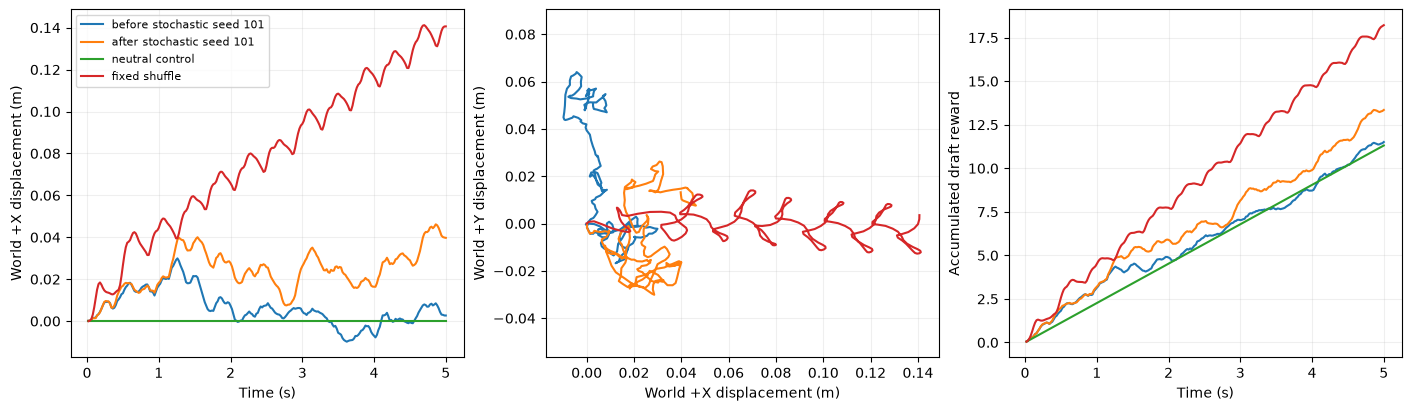

In [8]:
# EVALUATE: no weight updates. Keep seeds/settings fixed between comparisons.
evaluation_directory = run_directory / f'evaluation-{updates:05d}-{datetime.now(timezone.utc).strftime("%H%M%S%f")}'
evaluation_directory.mkdir(parents=True, exist_ok=False)
evaluations = []
for seed in SETTINGS['eval_seeds']:
    for label, network in (('before', initial_actor), ('after', actor)):
        evaluations.append(collect(network, observation_from, sample_action, reward_terms, SETTINGS,
                                   seed=seed, label=f'{label} stochastic seed {seed}'))
for label, network in (('before mean', initial_actor), ('after mean', actor)):
    evaluations.append(collect(network, observation_from, sample_action, reward_terms,
                               dict(SETTINGS, deterministic=True), seed=SETTINGS['eval_seeds'][0], label=label))
for label, control in (('neutral control', lambda state: np.zeros(18)), ('fixed shuffle', geometry_gait)):
    evaluations.append(collect(None, observation_from, sample_action, reward_terms, SETTINGS,
                               seed=SETTINGS['eval_seeds'][0], label=label, control=control))
for index, episode in enumerate(evaluations):
    save_episode(episode, evaluation_directory / f'{index:02d}')
evaluation_table = pd.DataFrame([summary(e) for e in evaluations])
evaluation_table.to_csv(evaluation_directory / 'comparison.csv', index=False)
# Select one paired seed and controls for replay. Other recordings remain available.
view_episodes = [evaluations[0], evaluations[1], evaluations[-2], evaluations[-1]]
# Replays open before the score comparison, so motion stays beside its measurements.  
# viewers = [e['recording'].watch(evaluation_directory / 'views', speed=0.5) for e in view_episodes] 
from spider.recording import launch_replay_grid
viewer = launch_replay_grid(
    [e['recording'].replay for e in view_episodes],
    evaluation_directory / 'views', speed=0.5,
)
display(evaluation_table)
plot_evaluations(view_episodes)
print('Saved evaluation:', evaluation_directory)

### Evidence

Compare fixed seeds, deterministic policies, and controls. Inspect forward/sideways motion,
contacts, falls, and reward terms. A higher score is not proof of walking.

Preserve REINFORCE checkpoints and failures. Keep the task and evaluation fixed when changing
algorithms. Use [TODO.md](../../TODO.md) for walking acceptance and population evaluation.

## Optional contract notes

Record your observation, action map, timing, reward, horizon, gamma, and boundary decisions here.
The remaining stubs are scratch space; the training loop above uses the editable learning functions.

In [9]:
# Fill these after discussing the proposal. None means undecided, not a default.
PHYSICS_STEPS = None
HORIZON_ACTIONS = None
GAMMA = None
ACTION_LOW = None
ACTION_HIGH = None
OFFSET_SCALE_RAD = None  # If using normalized actions; document scalar vs per-joint scale.
SEEDS = None             # Fixed comparison seeds, chosen before runs.

# Once PHYSICS_STEPS is chosen:
# print("Policy action duration (s):", PHYSICS_STEPS * sim.model.opt.timestep)

### Observation

Record shape, units, order, and frame. Inspect raw scales and omitted state.

In [10]:
def observe(state):
    """MeasuredState -> observation vector in the documented order."""
    raise NotImplementedError("Choose and implement the observation.")

In [11]:
# Run after implementing observe. Reset only; no rollout.
# first = observe(sim.reset())
# second = observe(sim.reset())
# assert first.ndim == 1 and np.isfinite(first).all()
# np.testing.assert_array_equal(first, second)
# display(pd.DataFrame({"index": range(first.size), "reset_value": first}))
# Compare values with your units/frame table. Add named plots after the signed probes.

### Action

The adapter accepts 18 neutral-relative radian offsets. Inspect requested versus applied targets and clipping.

In [12]:
def action_to_offsets(action):
    """Return (offsets_rad, info) for one policy action of shape (18,).

    info must preserve policy input, scaling, and any policy-space clipping.
    The transition adds requested/applied physical targets and their clipping flags.
    """
    raise NotImplementedError("Define bounds, scaling, and stored-action semantics.")

### Reward

Name each term and its intended behavior. Compare scores with actual motion.

In [13]:
def reward_terms(before, action, after, info):
    """Return a dict of named, weighted scalar contributions; reward is their sum."""
    raise NotImplementedError("Implement your proposed task reward.")

### Episodes

Record termination, truncation, horizon, gamma, and return handling at each boundary.

In [14]:
def episode_boundary(before, after, action_index, info):
    """Return (terminated, truncated, reason); action_index is zero-based."""
    raise NotImplementedError("Implement the agreed episode rules.")

### Transition

Keep both observations, the sampled action, applied targets, reward terms, times, and boundary flags.

In [15]:
def transition(simulation, before, action, action_index):
    """Return (sample, after).

    sample = (obs_t, action_t, reward_t, obs_t1, terminated, info)
    after is the next MeasuredState used by the following call.
    """
    raise NotImplementedError("Compose the agreed contract using LearningSimulation.step.")

### Comparison

Use the same conditions for learned policies, neutral, and fixed shuffle. Replay before interpreting scores.

In [16]:
# Implement the bounded collector after reviewing sections 2–7.
# Use transition(...) for each action. Stop at termination or truncation.
# Keep the fixed shuffle, neutral, and seeded random policies separate.
# Record states for replay with spider.recording.TreatmentReplay.
# No rollout or training runs in this scaffold.

### Dataset

Save aligned transitions, settings, weights, and exact states. Reload an artifact before trusting it.

In [17]:
# Add collection, alignment assertions, and artifact save/load here
# after the transition contract is reviewed. Keep each operation in a small cell.

### Review

Record the observed failure, your explanation, and the next change. Preparation does not earn a capability.